In [1]:
import pandas as pd
import json
import numpy as np
import os
import torch
from PIL import Image
from mmengine.config import Config
from transformers import set_seed
import random
import cv2
import h5py
import logging
from logging import Logger
from tqdm import tqdm
from datetime import datetime
from sklearn.metrics import precision_recall_curve, roc_auc_score, accuracy_score

/home/firdavs/miniconda3/envs/firdavs/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LOGGING_PATH = f'/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/logging/evaluate_vis_embs-dt=({datetime.now().strftime("%Y-%m-%d-%H-%M")}).log'
EMBEDDINGS_DIR = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/embeddings/vision/'
OUTPUT_DIR = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/outputs/evals/'
ALL_ANNOTATIONS_PATH = '/home/firdavs/surgery/surgical_fb_generation/SurgicalFeedbackGeneration/data/urology-related/annotations/cmb_all_mapped.csv'

def set_seed_all(seed, logger: Logger = None):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    set_seed(seed)
    print(f"Set seed: {seed}")
    if logger:
        logger.info(f"Set seed: {seed}")

set_seed_all(SEED)

Set seed: 42


In [3]:
def load_tmp_df():
    dir_ = '/home/firdavs/surgery/rafal_experiments/fbk_cuts_with_instruments'
    tmp_dfs = []
    for file in os.listdir(dir_):
        path = os.path.join(dir_, file)
        if not path.endswith('.csv'): continue
        tmp_df = pd.read_csv(path)
        tmp_dfs.append(tmp_df)
    tmp_df = pd.concat(tmp_dfs)
    tmp_df = tmp_df.drop(columns=['Unnamed: 0'])
    tmp_df.sort_values(by=['Case', 'Timestamp'], inplace=True)
    tmp_df.reset_index(drop=True, inplace=True)
    return tmp_df
tmp_df = load_tmp_df()

In [4]:
def load_annotations_df():
    annotations_df = pd.read_csv(ALL_ANNOTATIONS_PATH)
    fbk_cols = [col for col in annotations_df.columns if col.startswith('f_')]
    annotations_df = annotations_df[['Dialogue', 'Timestamp', 'Case', 'cholec-instrument', 'cholec-verb', 'cholec-target'] + fbk_cols]
    annotations_df['Timestamp'] = annotations_df['Timestamp'].apply(lambda x: f"{int(x.split(':')[0]):02d}:{int(x.split(':')[1]):02d}:{int(x.split(':')[2]):02d}")
    annotations_df.sort_values(by=['Case', 'Timestamp'], inplace=True)
    annotations_df.reset_index(drop=True, inplace=True)
    return annotations_df

all_annotations_df = load_annotations_df()
all_annotations_df['cvid'] = tmp_df['cvid']

In [5]:
all_annotations_df[all_annotations_df['cvid'] == 'c1_s0_2-20-5.avi']

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid
327,"more retraction, please... on the prostate sid...",10:57:30,1,NaN,NaN,NaN,0,0,1,0,1,0,0.0,c1_s0_2-20-5.avi


In [6]:
def load_procedures_df():
    procedures_df = pd.read_parquet('../data/urology-related/procedures.parquet')
    return procedures_df

def load_teaching_steps_df():
    teaching_steps_df = pd.read_parquet('../data/urology-related/teaching_steps.parquet')
    teaching_steps_df = teaching_steps_df.sort_values(by=['case_id', 'end_secs'])
    teaching_steps_df.reset_index(drop=True, inplace=True)
    for i in range(len(teaching_steps_df)):
        if i == 0:
            continue
        if teaching_steps_df.loc[i, 'case_id'] == teaching_steps_df.loc[i-1, 'case_id']:
            teaching_steps_df.loc[i, 'start_secs'] = teaching_steps_df.loc[i-1, 'end_secs']
    return teaching_steps_df

procedures_df = load_procedures_df()
teaching_steps_df = load_teaching_steps_df()

In [7]:
teaching_steps_df['duration'] = teaching_steps_df['end_secs'] - teaching_steps_df['start_secs']
teaching_steps_df['duration'].mean()

np.float64(546.4744376278119)

In [8]:
teaching_step_case_count = []
for case_id in teaching_steps_df['case_id'].unique():
    case_df = teaching_steps_df[teaching_steps_df['case_id'] == case_id]
    teaching_step_case_count.append(len(case_df))
np.mean(teaching_step_case_count)

np.float64(15.28125)

In [ ]:
def add_vis_embs(name, annotations_df, force=False):
    annotations_df = annotations_df.copy()
    if name not in annotations_df.columns or force:
        embs_path = os.path.join(EMBEDDINGS_DIR, f"{name}_fbk_vis_embs.h5")
        embs_h5 = h5py.File(embs_path, 'r')
        annotations_df[f'{name}_vis_embs'] = annotations_df['cvid'].apply(lambda x: embs_h5[x][:] if x in embs_h5 else None)
        embs_h5.close()
    return annotations_df

all_annotations_df = add_vis_embs('surgvlp', all_annotations_df)
all_annotations_df = add_vis_embs('hecvl', all_annotations_df)
all_annotations_df = add_vis_embs('peskavlp', all_annotations_df)
all_annotations_df = add_vis_embs('videomae_urology', all_annotations_df)
all_annotations_df = add_vis_embs('videomae_cholect45', all_annotations_df)

: 

In [ ]:
sample_df_IVT = all_annotations_df.dropna(subset=['cholec-instrument', 'cholec-verb', 'cholec-target']).sample(n=3, random_state=0)
sample_df_I = all_annotations_df.dropna(subset=['cholec-instrument']).sample(n=1, random_state=0)
sample_df_V = all_annotations_df.dropna(subset=['cholec-verb']).sample(n=1, random_state=0)
sample_df_T = all_annotations_df.dropna(subset=['cholec-target']).sample(n=1, random_state=0)
sample_indices = list(sample_df_IVT.index) + list(sample_df_I.index) + list(sample_df_V.index) + list(sample_df_T.index)
annotations_df = all_annotations_df[~all_annotations_df.index.isin(sample_indices)]
sample_df = all_annotations_df[all_annotations_df.index.isin(sample_indices)]

## Evaluate

In [12]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, average_precision_score, confusion_matrix
from sklearn.neural_network import MLPClassifier
import numpy as np
from imblearn.over_sampling import SMOTE

def evaluate(embeddings, labels, metric_avg='weighted', sampler=None, num_folds=5, hidden_layer_sizes=(128, 64)):
    skf = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

    auprc_scores = []
    auroc_scores = []
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    confusion_matrices = []

    # Unique labels
    unique_labels = list(set(labels))

    for train_index, test_index in skf.split(embeddings, labels):
        X_train, X_test = embeddings[train_index], embeddings[test_index]
        y_train, y_test = labels[train_index], labels[test_index]
        
        if sampler is not None:
            X_train, y_train = sampler.fit_resample(X_train, y_train)
        
        # Initialize and train a 2-layer MLP with ReLU activation
        model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu', max_iter=1000, random_state=42)
        model.fit(X_train, y_train)
        
        # Predict the test set
        y_pred = model.predict(X_test)
        y_pred_prob = model.predict_proba(X_test)
        
        # Evaluate metrics
        auprc_scores.append(average_precision_score(y_test, y_pred_prob, average=metric_avg))
        auroc_scores.append(roc_auc_score(y_test, y_pred_prob, multi_class='ovo', average=metric_avg if metric_avg is not None else 'weighted'))
        accuracy_scores.append(accuracy_score(y_test, y_pred, normalize=True))
        precision_scores.append(precision_score(y_test, y_pred, zero_division=0, average=metric_avg))
        recall_scores.append(recall_score(y_test, y_pred, zero_division=0, average=metric_avg))
        f1_scores.append(f1_score(y_test, y_pred, zero_division=0, average=metric_avg))
        confusion_matrices.append(confusion_matrix(y_test, y_pred, labels=unique_labels))
    
    mean_auprc = np.mean(auprc_scores)
    mean_auroc = np.mean(auroc_scores)
    mean_accuracy = np.mean(accuracy_scores)
    mean_precision = np.mean(precision_scores)
    mean_recall = np.mean(recall_scores)
    mean_f1 = np.mean(f1_scores)
    
    final_model = MLPClassifier(hidden_layer_sizes=hidden_layer_sizes, activation='relu', max_iter=1000, random_state=42)
    final_model.fit(embeddings, labels)

    return {
        'auprc_scores': auprc_scores,
        'auroc_scores': auroc_scores,
        'accuracy_scores': accuracy_scores,
        'precision_scores': precision_scores,
        'recall_scores': recall_scores,
        'f1_scores': f1_scores,
        'auprc_mean': mean_auprc,
        'auroc_mean': mean_auroc,
        'accuracy_mean': mean_accuracy,
        'precision_mean': mean_precision,
        'recall_mean': mean_recall,
        'f1_mean': mean_f1,
        'confusion_matrix': np.sum(confusion_matrices, axis=0),
        'confusion_matrix_labels': unique_labels,
    }, final_model

### 1) Vision

In [23]:
def get_vision_embeddings_and_labels(annotations_df, task, model, label_filter:int = None):
    df = annotations_df.dropna(subset=[f'{model}_vis_embs']).copy()
    if label_filter is not None:    # Remove labels with less than label_filter counts
        df = df[df[f'cholec-{task}'].map(df[f'cholec-{task}'].value_counts()) >= label_filter]
    embeddings_avg = np.array(df[f'{model}_vis_embs'].values.tolist()).mean(axis=1)
    labels = np.array(df[f"cholec-{task}"].values.tolist())
    return embeddings_avg, labels

task = 'instrument'
model = 'peskavlp'
embeddings_avg, labels = get_vision_embeddings_and_labels(annotations_df, task, model, label_filter=8)
metrics, final_model = evaluate(embeddings_avg, labels, metric_avg='weighted', num_folds=5)

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Mean AUPRC: 0.5683
Mean AUROC: 0.6608
Mean Accuracy: 0.5269
Mean Precision: 0.4896
Mean Recall: 0.5269
Mean F1: 0.4997


In [38]:
def get_sample_predictions(final_model, sample_df, task, model, modality):
    if modality == 'vision':
        embeddings_avg, labels = get_vision_embeddings_and_labels(sample_df, task, model)
        pred = final_model.predict(embeddings_avg)
    elif modality == 'vision+proc+step':
        vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(sample_df, procedures_df, teaching_steps_df, task, model)
        embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
        pred = final_model.predict(embeddings_comb)
    return pred

In [24]:
vision_results_rows = []
for model in ['surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45']:
    for task in ['instrument', 'verb', 'target']:
        print(f"Model: {model}, Task: {task}")
        embeddings_avg, labels = get_vision_embeddings_and_labels(annotations_df, task, model, label_filter=8)
        metrics, final_model = evaluate(embeddings_avg, labels, metric_avg='weighted', num_folds=5)
        sample_predictions = get_sample_predictions(final_model, sample_df, task, model, 'vision')
        vision_results_rows.append({
            'model': model,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
            'sample_predictions': sample_predictions
        })
vision_results_df = pd.DataFrame(vision_results_rows)

Model: surgvlp, Task: instrument
Model: surgvlp, Task: verb
Model: surgvlp, Task: target
Model: hecvl, Task: instrument
Model: hecvl, Task: verb
Model: hecvl, Task: target
Model: peskavlp, Task: instrument
Model: peskavlp, Task: verb
Model: peskavlp, Task: target
Model: videomae_urology, Task: instrument
Model: videomae_urology, Task: verb
Model: videomae_urology, Task: target
Model: videomae_cholect45, Task: instrument
Model: videomae_cholect45, Task: verb
Model: videomae_cholect45, Task: target


In [26]:
vision_results_df.to_csv(os.path.join(OUTPUT_DIR, 'vision_results.csv'), index=False)
vision_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels,sample_predictions
0,surgvlp,instrument,0.550646,0.609331,0.459310,0.455330,0.459310,0.445539,"[[8, 5, 4, 3], [7, 49, 13, 9], [1, 15, 9, 4], ...","[clipper, bipolar, scissors, grasper]","[bipolar, scissors, bipolar, bipolar, clipper,..."
1,surgvlp,verb,0.523451,0.669195,0.452218,0.427127,0.452218,0.429935,"[[1, 3, 0, 1, 3], [1, 18, 0, 7, 15], [0, 3, 2,...","[coagulate, cut, clip, retract, grasp]","[cut, grasp, cut, cut, grasp, grasp]"
2,surgvlp,target,0.871248,0.768980,0.845320,0.798472,0.845320,0.814353,"[[113, 1, 5], [8, 1, 0], [8, 0, 6]]","[blood_vessel, cystic_artery, peritoneum]","[blood_vessel, blood_vessel, blood_vessel, blo..."
3,hecvl,instrument,0.525839,0.627488,0.479540,0.493409,0.479540,0.470583,"[[8, 6, 3, 3], [5, 48, 14, 11], [2, 13, 11, 3]...","[clipper, bipolar, scissors, grasper]","[grasper, scissors, scissors, scissors, scisso..."
4,hecvl,verb,0.537469,0.687120,0.490121,0.481148,0.490121,0.477507,"[[0, 3, 0, 1, 4], [2, 17, 1, 8, 13], [0, 4, 2,...","[coagulate, cut, clip, retract, grasp]","[grasp, grasp, grasp, grasp, grasp, grasp]"
5,hecvl,target,0.883415,0.751504,0.845813,0.800515,0.845813,0.817661,"[[113, 1, 5], [9, 0, 0], [7, 0, 7]]","[blood_vessel, cystic_artery, peritoneum]","[blood_vessel, blood_vessel, blood_vessel, blo..."
6,peskavlp,instrument,0.568282,0.660777,0.526897,0.489605,0.526897,0.499712,"[[6, 8, 5, 1], [5, 60, 7, 6], [3, 11, 8, 7], [...","[clipper, bipolar, scissors, grasper]","[bipolar, grasper, bipolar, scissors, scissors..."
7,peskavlp,verb,0.584395,0.716292,0.528024,0.516774,0.528024,0.506784,"[[1, 0, 0, 1, 6], [2, 22, 1, 6, 10], [0, 1, 2,...","[coagulate, cut, clip, retract, grasp]","[grasp, grasp, grasp, retract, grasp, grasp]"
8,peskavlp,target,0.900756,0.822815,0.873645,0.843742,0.873645,0.855487,"[[114, 1, 4], [7, 2, 0], [5, 1, 8]]","[blood_vessel, cystic_artery, peritoneum]","[blood_vessel, blood_vessel, blood_vessel, blo..."
9,videomae_urology,instrument,0.433664,0.501564,0.391264,0.380060,0.391264,0.369836,"[[3, 12, 3, 2], [6, 48, 16, 8], [3, 17, 5, 4],...","[clipper, bipolar, scissors, grasper]","[bipolar, bipolar, bipolar, clipper, grasper, ..."


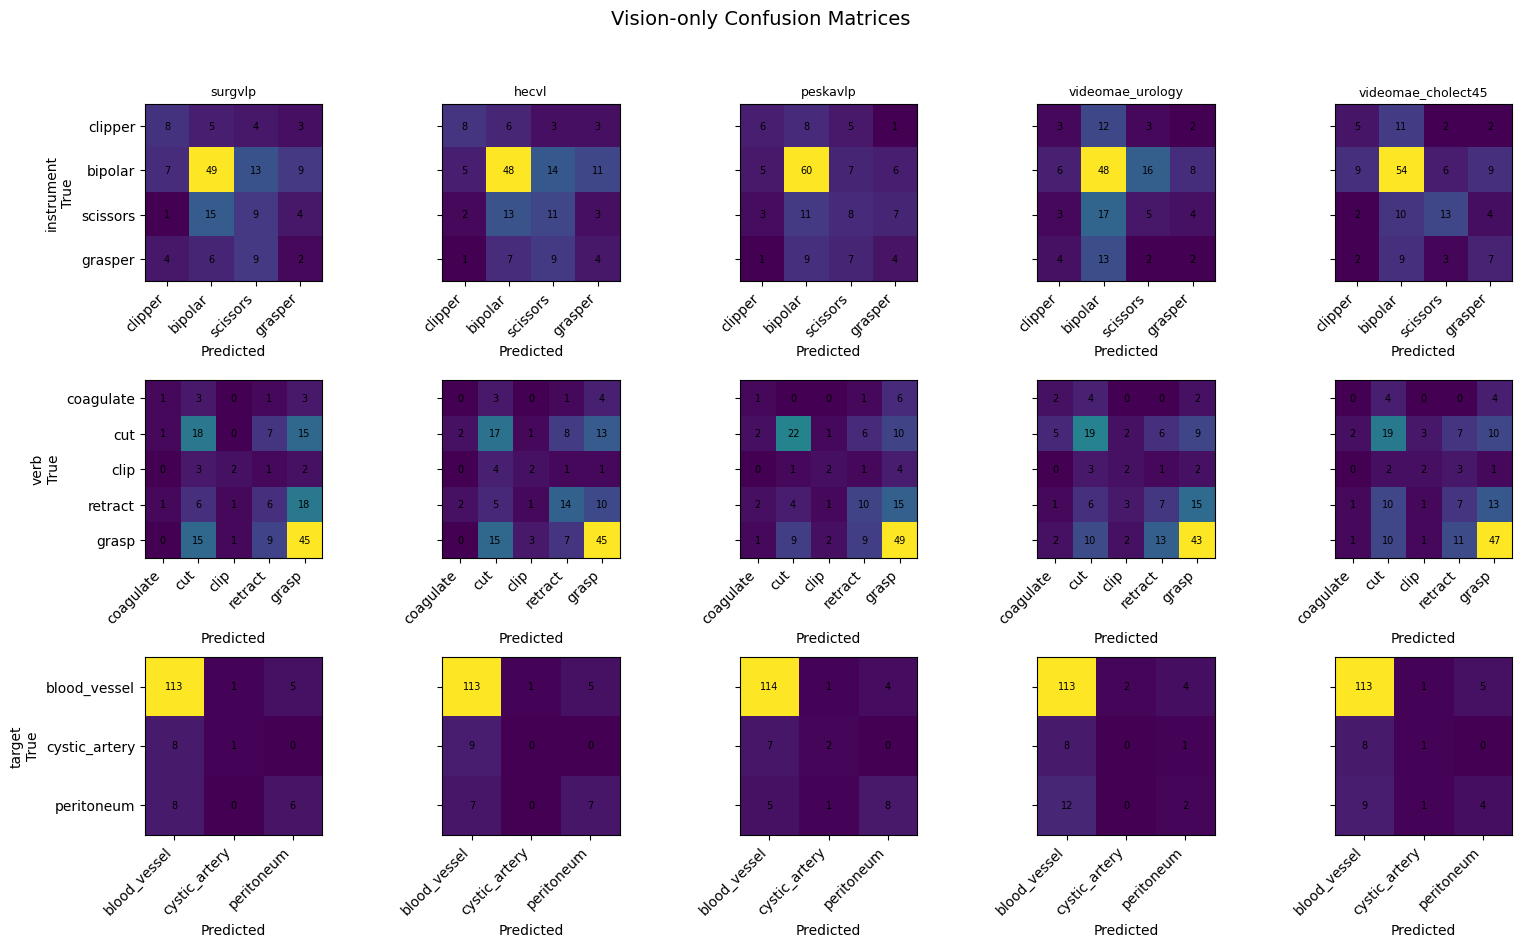

In [27]:
def plot_confusion_matrices(confusion_matrices_df, suptitle):
    import matplotlib.pyplot as plt
    import numpy as np

    models_order = ['surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45']
    tasks_order  = ['instrument', 'verb', 'target']

    # df_plot = vision_confusion_matrices_df.set_index(['model', 'task'])
    df_plot = confusion_matrices_df.set_index(['model', 'task'])
    

    # --- 3 rows (tasks) × 5 columns (models) -----------------
    n_rows, n_cols = len(tasks_order), len(models_order)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows))
    # fig.suptitle("Vision-only Confusion Matrices", fontsize=14)
    fig.suptitle(suptitle, fontsize=14)

    for i, task in enumerate(tasks_order):               # rows = tasks (top → bottom)
        for j, model in enumerate(models_order):         # cols = models (left → right)
            ax = axes[i, j]
            row = df_plot.loc[(model, task)]
            cm  = np.array(row['confusion_matrix'])
            labels = row['confusion_matrix_labels']

            ax.imshow(cm, origin='upper')                # default colormap
            ax.set_xticks(range(len(labels)), labels, rotation=45, ha='right')
            ax.set_yticks(range(len(labels)), labels if j == 0 else [])  # y‑labels only on 1st col
            ax.set_title(model, fontsize=9) if i == 0 else None          # titles only on top row
            if j == 0:
                ax.set_ylabel(f'{task}\nTrue')
            ax.set_xlabel('Predicted')

            for (x, y), v in np.ndenumerate(cm):
                ax.text(y, x, int(v), ha='center', va='center', fontsize=7)

    fig.tight_layout(rect=[0, 0, 1, 0.95])  # leave room for suptitle
    plt.show()

plot_confusion_matrices(vision_results_df, 'Vision-only Confusion Matrices')

### 2) Vision-Language

In [45]:
def get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, task, model_name, label_filter:int = None):
    df = annotations_df.dropna(subset=[f'{model_name}_vis_embs']).copy()
    if label_filter is not None:    # Remove labels with less than label_filter counts
        df = df[df[f'cholec-{task}'].map(df[f'cholec-{task}'].value_counts()) >= label_filter]
    
    # Vision embeddings
    vis_embs_avg = np.array(df[f'{model_name}_vis_embs'].values.tolist()).mean(axis=1)
    
    emb_col = ''
    if model_name == 'surgvlp': emb_col = 'SurgVLP'
    elif model_name == 'hecvl': emb_col = 'HecVL'
    elif model_name == 'peskavlp': emb_col = 'PeskaVLP'
    elif model_name == 'videomae_urology' or model_name == 'videomae_cholect45': emb_col = 'MedEmbed_small'
    else:
        raise ValueError(f"Model name {model_name} is not supported.")
    print(f"Embedding column: {emb_col}")
    
    # Procedure embeddings
    procedure_embs = []
    for i in range(len(df)):
        case = df.iloc[i]['Case']
        tmp_df = procedures_df[procedures_df['case_id'] == case]
        procedure_embs.append(tmp_df[f"procedure_defn_emb-{emb_col}"].values[0])
    procedure_embs = np.array(procedure_embs)
    
    # Teaching step embeddings
    teaching_step_embs = []
    df['secs'] = df['cvid'].apply(lambda x: sum([a*b for a,b in zip(map(int, x.split('_')[-1][:-4].split('-')), [3600, 60, 1])]))
    for i in range(len(df)):
        secs = df.iloc[i]['secs']
        case = df.iloc[i]['Case']
        tmp_df = teaching_steps_df[teaching_steps_df['case_id'] == case]
        tmp_df = tmp_df[(tmp_df['start_secs'] <= secs) & (tmp_df['end_secs'] > secs)]
        if len(tmp_df) == 0:
            raise ValueError(f"No teaching step found for case {case} and timestamp {secs}")
        if len(tmp_df) > 1:
            raise ValueError(f"Multiple teaching steps found for case {case} and timestamp {secs}")
        teaching_step_embs.append(tmp_df[f"teaching_step_defn_emb-{emb_col}"].values[0])
    teaching_step_embs = np.array(teaching_step_embs)
    
    # Labels
    labels = np.array(df[f"cholec-{task}"].values.tolist())
    
    return vis_embs_avg, procedure_embs, teaching_step_embs, labels

task = 'instrument'
model_name = 'surgvlp'
vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, task, model_name, label_filter=10)
embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
metrics, final_model = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Embedding column: SurgVLP
Mean AUPRC: 0.5718
Mean AUROC: 0.6303
Mean Accuracy: 0.5064
Mean Precision: 0.5309
Mean Recall: 0.5064
Mean F1: 0.5065


In [46]:
task = 'instrument'
model_name = 'surgvlp'
vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, task, model_name, label_filter=10)
embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
metrics, final_model = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))

print(f"Mean AUPRC: {metrics['auprc_mean']:.4f}")
print(f"Mean AUROC: {metrics['auroc_mean']:.4f}")
print(f"Mean Accuracy: {metrics['accuracy_mean']:.4f}")
print(f"Mean Precision: {metrics['precision_mean']:.4f}")
print(f"Mean Recall: {metrics['recall_mean']:.4f}")
print(f"Mean F1: {metrics['f1_mean']:.4f}")

Embedding column: SurgVLP
Mean AUPRC: 0.5718
Mean AUROC: 0.6303
Mean Accuracy: 0.5064
Mean Precision: 0.5309
Mean Recall: 0.5064
Mean F1: 0.5065


In [48]:
vl_both_results_rows = []
for model_name in ['surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45']:
    for task in ['instrument', 'verb', 'target']:
        print(f"Model: {model_name}, Task: {task}")
        vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, task, model_name, label_filter=8)
        embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs, teaching_step_embs], axis=1)
        metrics, final_model = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))
        sample_predictions = get_sample_predictions(final_model, sample_df, task, model_name, 'vision+proc+step')
        vl_both_results_rows.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
            'sample_predictions': sample_predictions
        })
vl_both_results_df = pd.DataFrame(vl_both_results_rows)

Model: surgvlp, Task: instrument
Embedding column: SurgVLP
Embedding column: SurgVLP
(6, 2304)
Model: surgvlp, Task: verb
Embedding column: SurgVLP
Embedding column: SurgVLP
(6, 2304)
Model: surgvlp, Task: target
Embedding column: SurgVLP
Embedding column: SurgVLP
(6, 2304)
Model: hecvl, Task: instrument
Embedding column: HecVL
Embedding column: HecVL
(6, 2304)
Model: hecvl, Task: verb
Embedding column: HecVL
Embedding column: HecVL
(6, 2304)
Model: hecvl, Task: target
Embedding column: HecVL
Embedding column: HecVL
(6, 2304)
Model: peskavlp, Task: instrument
Embedding column: PeskaVLP
Embedding column: PeskaVLP
(6, 2304)
Model: peskavlp, Task: verb
Embedding column: PeskaVLP
Embedding column: PeskaVLP
(6, 2304)
Model: peskavlp, Task: target
Embedding column: PeskaVLP
Embedding column: PeskaVLP
(6, 2304)
Model: videomae_urology, Task: instrument
Embedding column: MedEmbed_small
Embedding column: MedEmbed_small
(6, 1536)
Model: videomae_urology, Task: verb
Embedding column: MedEmbed_sma

In [50]:
vl_both_results_df.to_csv(os.path.join(OUTPUT_DIR, 'vl_both_results.csv'), index=False)
vl_both_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels,sample_predictions
0,surgvlp,instrument,0.571776,0.630286,0.506437,0.530905,0.506437,0.506538,"[[8, 6, 5, 1], [7, 49, 13, 9], [6, 9, 11, 3], ...","[clipper, bipolar, scissors, grasper]","[bipolar, scissors, bipolar, clipper, grasper,..."
1,surgvlp,verb,0.535612,0.681050,0.490121,0.509190,0.490121,0.477084,"[[2, 3, 0, 2, 1], [1, 17, 2, 6, 15], [0, 3, 2,...","[coagulate, cut, clip, retract, grasp]","[cut, cut, cut, cut, grasp, grasp]"
2,surgvlp,target,0.861754,0.764130,0.859360,0.826168,0.859360,0.839781,"[[113, 2, 4], [9, 0, 0], [4, 1, 9]]","[blood_vessel, cystic_artery, peritoneum]","[blood_vessel, blood_vessel, blood_vessel, blo..."
3,hecvl,instrument,0.514425,0.605767,0.471724,0.475237,0.471724,0.469241,"[[6, 9, 4, 1], [6, 49, 13, 10], [4, 9, 9, 7], ...","[clipper, bipolar, scissors, grasper]","[clipper, bipolar, bipolar, clipper, grasper, ..."
4,hecvl,verb,0.585508,0.707230,0.516129,0.520071,0.516129,0.503373,"[[1, 2, 0, 2, 3], [1, 18, 2, 5, 15], [0, 3, 2,...","[coagulate, cut, clip, retract, grasp]","[cut, coagulate, coagulate, grasp, grasp, grasp]"
5,hecvl,target,0.846581,0.707401,0.845074,0.817926,0.845074,0.829972,"[[111, 3, 5], [9, 0, 0], [4, 1, 9]]","[blood_vessel, cystic_artery, peritoneum]","[blood_vessel, blood_vessel, blood_vessel, blo..."
6,peskavlp,instrument,0.572812,0.662089,0.547356,0.517132,0.547356,0.520038,"[[6, 10, 3, 1], [5, 59, 8, 6], [4, 8, 12, 5], ...","[clipper, bipolar, scissors, grasper]","[bipolar, bipolar, bipolar, clipper, bipolar, ..."
7,peskavlp,verb,0.559976,0.690549,0.502823,0.511782,0.502823,0.483850,"[[1, 1, 0, 2, 4], [1, 18, 1, 9, 12], [0, 2, 2,...","[coagulate, cut, clip, retract, grasp]","[grasp, coagulate, cut, grasp, grasp, grasp]"
8,peskavlp,target,0.891616,0.804682,0.845320,0.837272,0.845320,0.838406,"[[110, 5, 4], [8, 1, 0], [4, 1, 9]]","[blood_vessel, cystic_artery, peritoneum]","[blood_vessel, blood_vessel, blood_vessel, blo..."
9,videomae_urology,instrument,0.448543,0.528676,0.418161,0.407271,0.418161,0.401042,"[[3, 12, 3, 2], [4, 50, 11, 13], [4, 14, 6, 5]...","[clipper, bipolar, scissors, grasper]","[bipolar, bipolar, bipolar, clipper, grasper, ..."


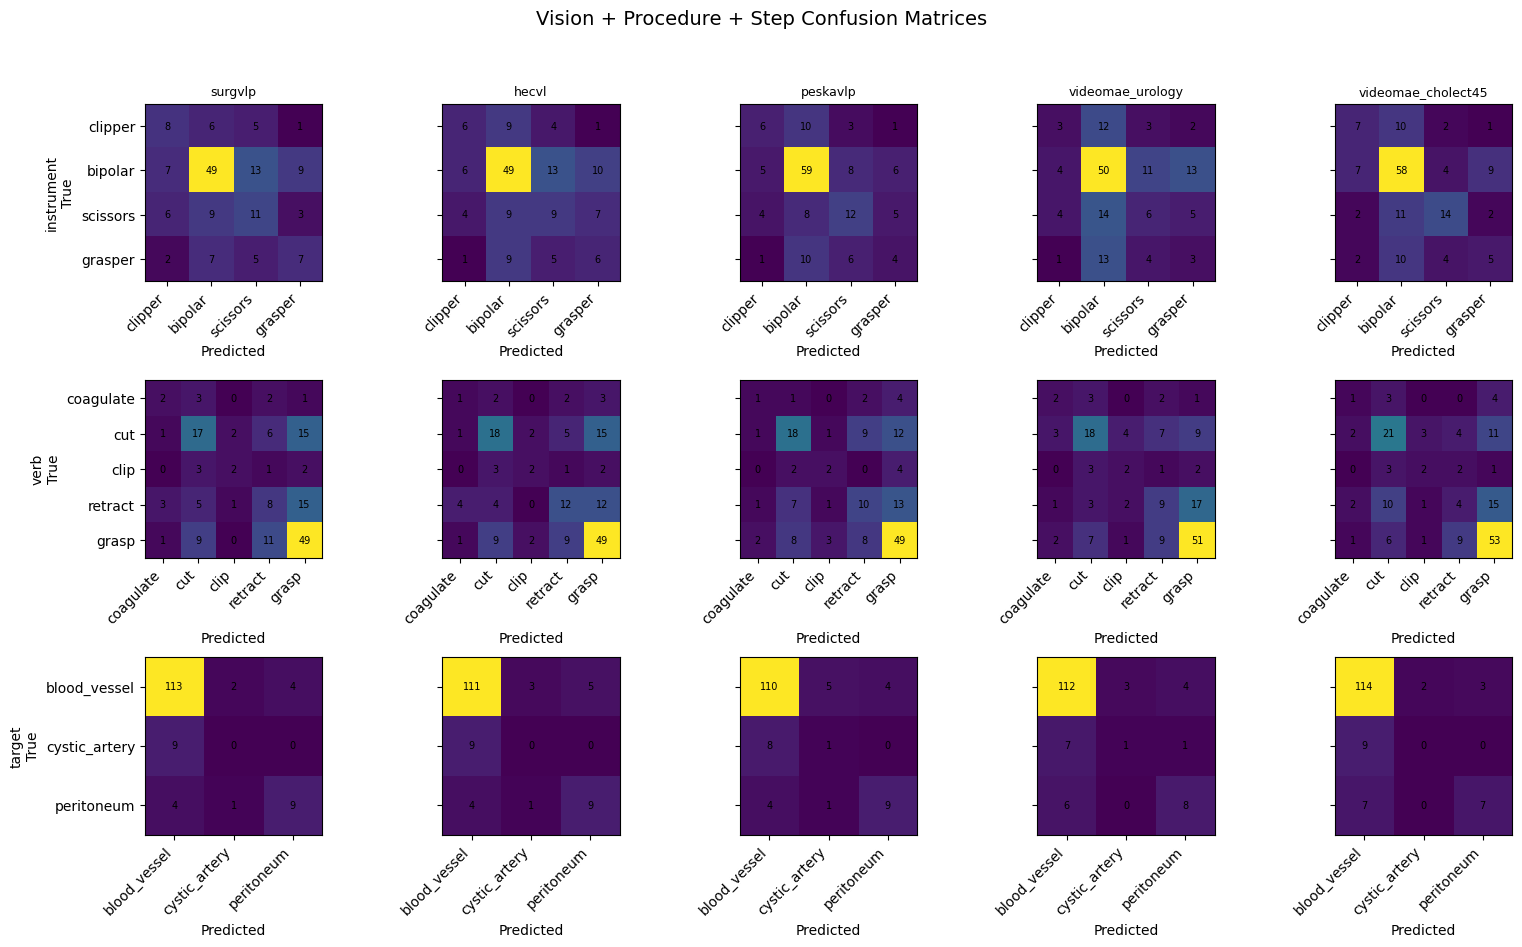

In [51]:
plot_confusion_matrices(vl_both_results_df, 'Vision + Procedure + Step Confusion Matrices')

In [21]:
vl_proc_results_rows = []
for model_name in ['surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45']:
    for task in ['instrument', 'verb', 'target']:
        print(f"Model: {model_name}, Task: {task}")
        vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, task, model_name, label_filter=10)
        embeddings_comb = np.concatenate([vis_embs_avg, procedure_embs], axis=1)
        metrics = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))
        vl_proc_results_rows.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
        })
vl_proc_results_df = pd.DataFrame(vl_proc_results_rows)

Model: surgvlp, Task: instrument
Embedding column: SurgVLP
Model: surgvlp, Task: verb
Embedding column: SurgVLP
Model: surgvlp, Task: target
Embedding column: SurgVLP
Model: hecvl, Task: instrument
Embedding column: HecVL
Model: hecvl, Task: verb
Embedding column: HecVL
Model: hecvl, Task: target
Embedding column: HecVL
Model: peskavlp, Task: instrument
Embedding column: PeskaVLP
Model: peskavlp, Task: verb
Embedding column: PeskaVLP
Model: peskavlp, Task: target
Embedding column: PeskaVLP
Model: videomae_urology, Task: instrument
Embedding column: MedEmbed_small
Model: videomae_urology, Task: verb
Embedding column: MedEmbed_small
Model: videomae_urology, Task: target
Embedding column: MedEmbed_small
Model: videomae_cholect45, Task: instrument
Embedding column: MedEmbed_small
Model: videomae_cholect45, Task: verb
Embedding column: MedEmbed_small
Model: videomae_cholect45, Task: target
Embedding column: MedEmbed_small


In [22]:
vl_proc_results_df.to_csv(os.path.join(OUTPUT_DIR, 'vl_proc_results.csv'), index=False)
vl_proc_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,surgvlp,instrument,0.534098,0.624034,0.463441,0.468949,0.463441,0.450464,"[[49, 10, 7, 14], [8, 7, 3, 4], [9, 3, 5, 5], ...","[bipolar, clipper, grasper, scissors]"
1,surgvlp,verb,0.539980,0.656425,0.474194,0.480589,0.474194,0.470647,"[[48, 11, 3, 9], [14, 6, 3, 9], [2, 1, 3, 4], ...","[grasp, retract, clip, cut]"
2,surgvlp,target,0.876606,0.774594,0.828966,0.795813,0.828966,0.808822,"[[112, 5, 4], [7, 8, 0], [9, 0, 1]]","[blood_vessel, peritoneum, cystic_artery]"
3,hecvl,instrument,0.541350,0.645056,0.430968,0.414119,0.430968,0.416507,"[[47, 8, 11, 14], [6, 8, 4, 4], [11, 3, 4, 4],...","[bipolar, clipper, grasper, scissors]"
4,hecvl,verb,0.606194,0.720900,0.551613,0.565802,0.551613,0.548483,"[[51, 8, 6, 6], [10, 13, 1, 8], [2, 2, 3, 3], ...","[grasp, retract, clip, cut]"
5,hecvl,target,0.882562,0.783151,0.842529,0.819422,0.842529,0.828978,"[[113, 3, 5], [4, 10, 1], [10, 0, 0]]","[blood_vessel, peritoneum, cystic_artery]"
6,peskavlp,instrument,0.580150,0.665219,0.490108,0.476565,0.490108,0.469247,"[[55, 9, 8, 8], [11, 7, 3, 1], [11, 0, 5, 6], ...","[bipolar, clipper, grasper, scissors]"
7,peskavlp,verb,0.605445,0.710489,0.505591,0.519495,0.505591,0.500943,"[[45, 17, 2, 7], [14, 9, 2, 7], [2, 2, 4, 2], ...","[grasp, retract, clip, cut]"
8,peskavlp,target,0.912226,0.860308,0.849195,0.834427,0.849195,0.835090,"[[114, 4, 3], [6, 8, 1], [8, 0, 2]]","[blood_vessel, peritoneum, cystic_artery]"
9,videomae_urology,instrument,0.492693,0.571312,0.470968,0.449423,0.470968,0.456169,"[[55, 3, 9, 13], [10, 6, 2, 4], [9, 5, 5, 3], ...","[bipolar, clipper, grasper, scissors]"


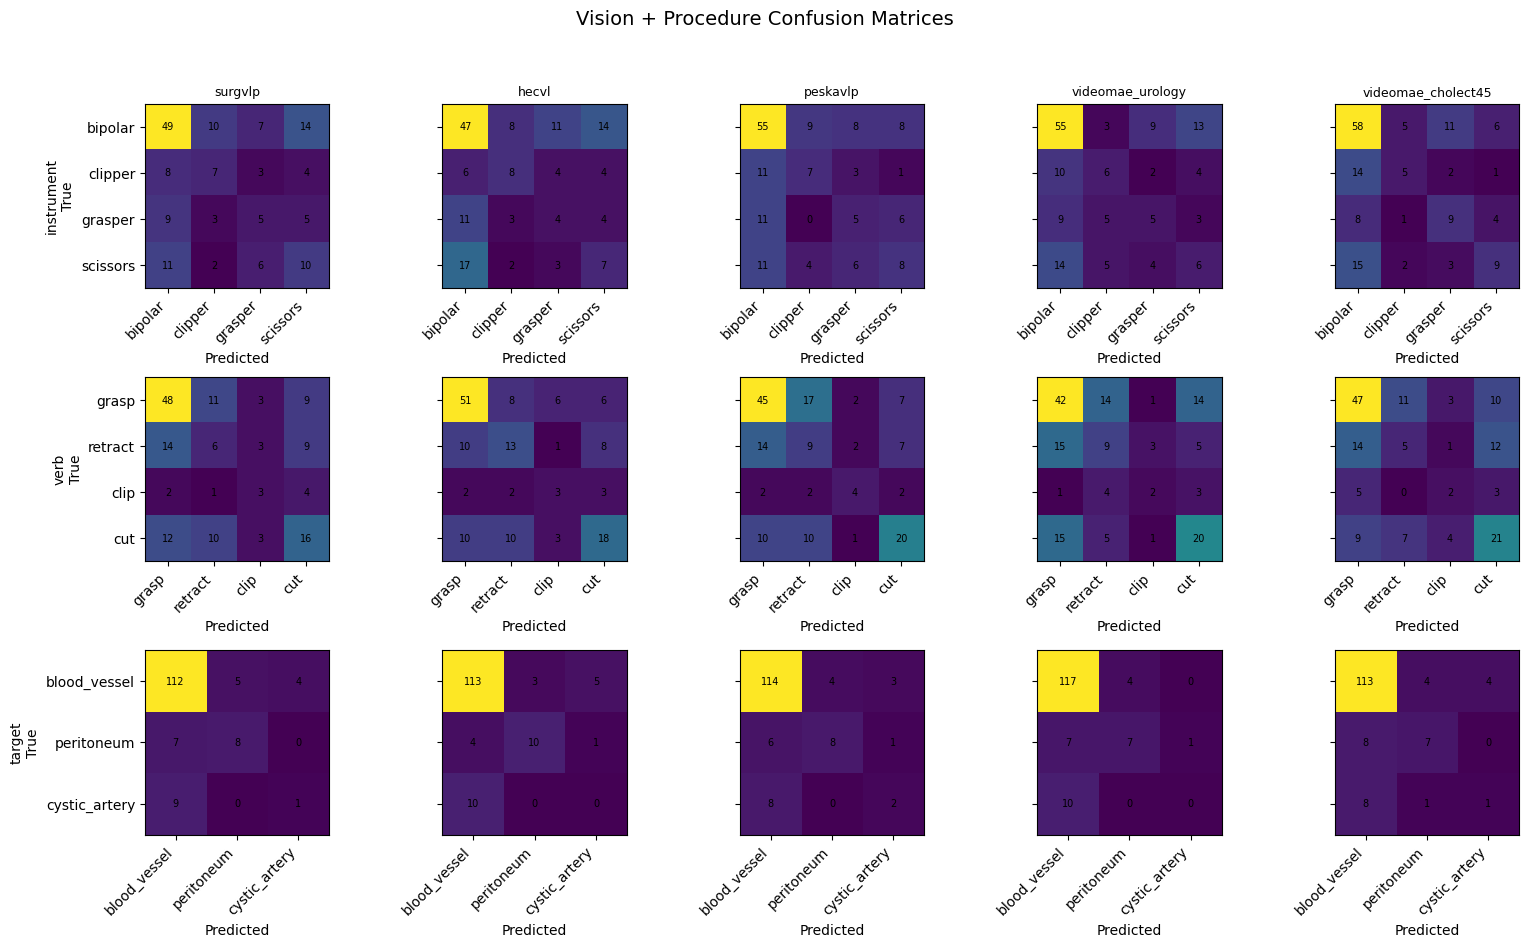

In [23]:
plot_confusion_matrices(vl_proc_results_df, 'Vision + Procedure Confusion Matrices')

In [24]:
vl_step_results_row = []
for model_name in ['surgvlp', 'hecvl', 'peskavlp', 'videomae_urology', 'videomae_cholect45']:
    for task in ['instrument', 'verb', 'target']:
        print(f"Model: {model_name}, Task: {task}")
        vis_embs_avg, procedure_embs, teaching_step_embs, labels = get_vl_embeddings_and_labels(annotations_df, procedures_df, teaching_steps_df, task, model_name, label_filter=10)
        embeddings_comb = np.concatenate([vis_embs_avg, teaching_step_embs], axis=1)
        metrics = evaluate(embeddings_comb, labels, metric_avg='weighted', num_folds=5, hidden_layer_sizes=(256, 64))
        vl_step_results_row.append({
            'model': model_name,
            'task': task,
            'auprc_mean': metrics['auprc_mean'],
            'auroc_mean': metrics['auroc_mean'],
            'accuracy_mean': metrics['accuracy_mean'],
            'precision_mean': metrics['precision_mean'],
            'recall_mean': metrics['recall_mean'],
            'f1_mean': metrics['f1_mean'],
            'confusion_matrix': metrics['confusion_matrix'],
            'confusion_matrix_labels': metrics['confusion_matrix_labels'],
        })
vl_step_results_df = pd.DataFrame(vl_step_results_row)

Model: surgvlp, Task: instrument
Embedding column: SurgVLP
Model: surgvlp, Task: verb
Embedding column: SurgVLP
Model: surgvlp, Task: target
Embedding column: SurgVLP
Model: hecvl, Task: instrument
Embedding column: HecVL
Model: hecvl, Task: verb
Embedding column: HecVL
Model: hecvl, Task: target
Embedding column: HecVL
Model: peskavlp, Task: instrument
Embedding column: PeskaVLP
Model: peskavlp, Task: verb
Embedding column: PeskaVLP
Model: peskavlp, Task: target
Embedding column: PeskaVLP
Model: videomae_urology, Task: instrument
Embedding column: MedEmbed_small
Model: videomae_urology, Task: verb
Embedding column: MedEmbed_small
Model: videomae_urology, Task: target
Embedding column: MedEmbed_small
Model: videomae_cholect45, Task: instrument
Embedding column: MedEmbed_small
Model: videomae_cholect45, Task: verb
Embedding column: MedEmbed_small
Model: videomae_cholect45, Task: target
Embedding column: MedEmbed_small


In [25]:
vl_step_results_df.to_csv(os.path.join(OUTPUT_DIR, 'vl_step_results.csv'), index=False)
vl_step_results_df

,model,task,auprc_mean,auroc_mean,accuracy_mean,precision_mean,recall_mean,f1_mean,confusion_matrix,confusion_matrix_labels
0,surgvlp,instrument,0.556279,0.658890,0.469892,0.474195,0.469892,0.466716,"[[49, 9, 9, 13], [7, 8, 2, 5], [9, 0, 7, 6], [...","[bipolar, clipper, grasper, scissors]"
1,surgvlp,verb,0.574135,0.686967,0.493763,0.520904,0.493763,0.498212,"[[44, 17, 2, 8], [13, 11, 2, 6], [2, 2, 3, 3],...","[grasp, retract, clip, cut]"
2,surgvlp,target,0.885739,0.806652,0.842759,0.817848,0.842759,0.827811,"[[112, 5, 4], [4, 10, 1], [9, 0, 1]]","[blood_vessel, peritoneum, cystic_artery]"
3,hecvl,instrument,0.544003,0.649565,0.483656,0.454115,0.483656,0.461714,"[[55, 4, 7, 14], [9, 7, 1, 5], [11, 0, 6, 5], ...","[bipolar, clipper, grasper, scissors]"
4,hecvl,verb,0.571301,0.696670,0.558495,0.559695,0.558495,0.549414,"[[52, 9, 2, 8], [11, 11, 3, 7], [3, 2, 2, 3], ...","[grasp, retract, clip, cut]"
5,hecvl,target,0.857587,0.730648,0.835862,0.813659,0.835862,0.821988,"[[112, 4, 5], [4, 10, 1], [10, 0, 0]]","[blood_vessel, peritoneum, cystic_artery]"
6,peskavlp,instrument,0.561189,0.669566,0.509032,0.498525,0.509032,0.498860,"[[54, 6, 9, 11], [7, 8, 3, 4], [11, 0, 6, 5], ...","[bipolar, clipper, grasper, scissors]"
7,peskavlp,verb,0.567419,0.676069,0.538710,0.550865,0.538710,0.537778,"[[47, 13, 3, 8], [13, 9, 3, 7], [3, 2, 3, 2], ...","[grasp, retract, clip, cut]"
8,peskavlp,target,0.897279,0.839345,0.849195,0.823071,0.849195,0.830383,"[[114, 3, 4], [5, 9, 1], [9, 0, 1]]","[blood_vessel, peritoneum, cystic_artery]"
9,videomae_urology,instrument,0.551298,0.632183,0.484086,0.496096,0.484086,0.474937,"[[54, 6, 6, 14], [10, 8, 2, 2], [8, 3, 6, 5], ...","[bipolar, clipper, grasper, scissors]"


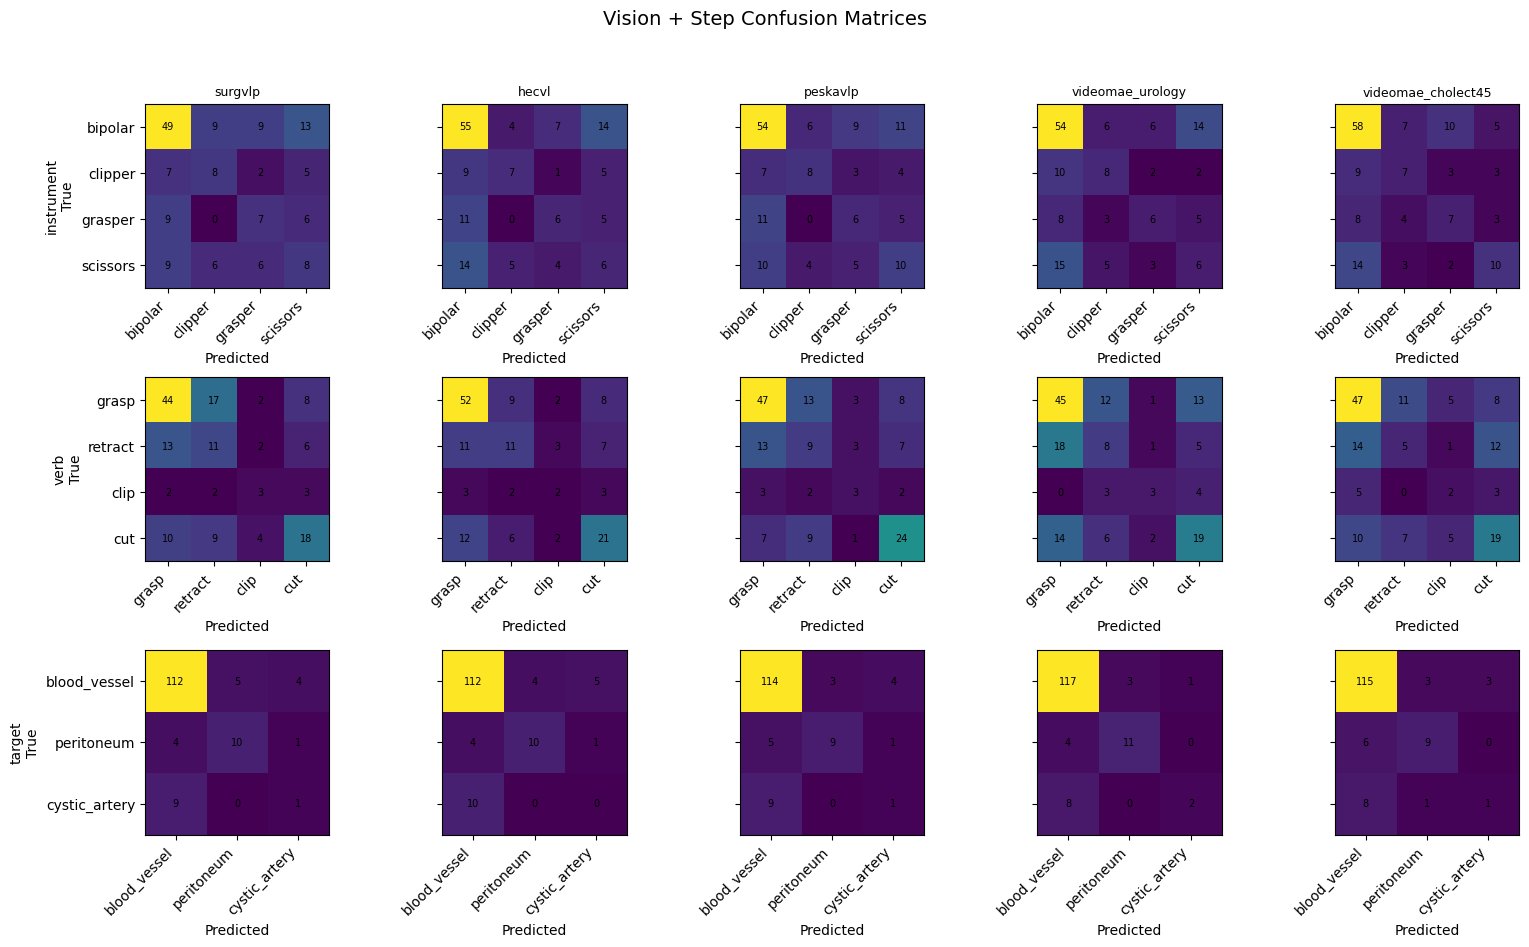

In [26]:
plot_confusion_matrices(vl_step_results_df, 'Vision + Step Confusion Matrices')

In [83]:
annotations_df.dropna(subset=['cholec-instrument', 'cholec-verb', 'cholec-target'])

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid,surgvlp_vis_embs,hecvl_vis_embs,peskavlp_vis_embs,videomae_urology_vis_embs,videomae_cholect45_vis_embs
1305,"only one clip to artery, wanna be safe",15:07:52,10,clipper,clip,cystic_artery,0,0,1,1,1,1,0.0,c10_s0_0-57-14.avi,"[[-0.218241, 0.14799017, -0.15066056, -0.04007...","[[-0.051978618, 0.07885238, -0.10014723, -0.06...","[[0.2720564, -0.10362105, -0.8061497, -0.06026...","[[0.8023892, -0.33413947, 0.45415547, 0.882377...","[[0.08080265, -0.43143338, -0.1326618, -1.0527..."
2388,that's it you can grab that peritoneum and tha...,08:56:32,19,grasper,grasp,peritoneum,0,0,1,0,1,0,0.0,c19_s0_0-42-46.avi,"[[-0.07247958, -0.36457115, -0.22653162, -0.22...","[[-0.092505164, 0.042876754, 0.16805689, -2.49...","[[0.7040797, -0.4253269, -0.5862603, 0.5330626...","[[0.31401753, -0.30575362, 0.48872352, 0.66644...","[[-0.30642292, -0.53710645, -0.272817, 0.79999..."
2665,"you can do a few things here, you can either c...",14:47:35,22,clipper,clip,blood_vessel,0,0,1,1,1,0,0.0,c22_s0_0-41-27.avi,"[[-0.20784745, -0.011039101, -0.14139679, -0.2...","[[0.050256267, 0.23370668, 0.12443544, -0.2394...","[[-0.029525891, -0.104582384, -0.32320666, -0....","[[0.5601449, -0.30259085, 0.35234943, 0.855686...","[[-0.56726885, -0.39179355, -0.29148817, 0.237..."
2691,when you cut you have to have a little bit of...,14:50:50,22,clipper,cut,blood_vessel,0,0,1,0,1,0,0.0,c22_s0_0-44-42.avi,"[[0.013509471, 0.022852337, -0.20486107, -0.16...","[[0.03765872, 0.05131695, -0.07111819, -0.0237...","[[-0.29935688, -0.082929455, -0.41667575, 0.44...","[[-0.11704118, -0.45124024, 0.3219164, 0.88945...","[[-1.5093155, -0.20689838, -0.26261327, -0.157..."
2708,i would probably put another clip on the vein ...,14:53:36,22,clipper,clip,blood_vessel,0,0,1,0,1,0,0.0,c22_s0_0-47-28.avi,"[[-0.10460509, -0.113670796, -0.03884057, -0.1...","[[-0.07703532, 0.19327506, 0.054483257, -0.083...","[[0.2199919, -0.15217066, -0.31848693, -0.0081...","[[0.006109887, -0.4031441, 0.23085995, 0.69598...","[[-0.87298733, -0.5664707, -0.1386519, -1.0360..."


## Sample Predictions

In [53]:
sample_df

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid,surgvlp_vis_embs,hecvl_vis_embs,peskavlp_vis_embs,videomae_urology_vis_embs,videomae_cholect45_vis_embs
134,buzz that thing before it sinks away... the red,09:42:58,1,bipolar,NaN,NaN,0,0,0,0,1,0,0.0,c1_s0_1-5-33.avi,"[[-0.035562385, 0.06860658, -0.29392123, -0.38...","[[-0.018331263, 0.24699728, 0.11388082, 0.0645...","[[0.21770735, -1.0188081, -0.40162438, 0.12273...","[[0.02555764, 0.02005744, -0.28562903, 1.71609...","[[-0.4577906, -0.16275048, -0.08540602, -0.181..."
1263,coag that,14:42:50,10,bipolar,coagulate,NaN,0,0,0,0,1,0,0.0,c10_s0_0-32-12.avi,"[[0.011161208, -0.1677331, 0.23768932, -0.2935...","[[-0.0056118667, 0.08058088, 0.008873083, -0.0...","[[-0.3599007, -0.32758605, 0.3134495, 0.052875...","[[0.13171989, -0.29451677, 0.38280702, 0.30161...","[[-0.35208073, -0.5624867, 0.14015989, 0.11463..."
1273,see theres a vein there,14:45:17,10,NaN,NaN,blood_vessel,0,0,1,0,1,0,0.0,c10_s0_0-34-39.avi,"[[-0.11618999, 0.03901406, 0.23957314, -0.0295...","[[0.053698428, 0.044785447, 0.11267051, -0.071...","[[-0.24620855, -0.15478101, 0.35461366, 0.7465...","[[0.95825166, -0.4324911, 0.39184508, 0.383991...","[[0.89390206, -0.48457006, 0.013383354, -0.081..."
1305,"only one clip to artery, wanna be safe",15:07:52,10,clipper,clip,cystic_artery,0,0,1,1,1,1,0.0,c10_s0_0-57-14.avi,"[[-0.218241, 0.14799017, -0.15066056, -0.04007...","[[-0.051978618, 0.07885238, -0.10014723, -0.06...","[[0.2720564, -0.10362105, -0.8061497, -0.06026...","[[0.8023892, -0.33413947, 0.45415547, 0.882377...","[[0.08080265, -0.43143338, -0.1326618, -1.0527..."
2388,that's it you can grab that peritoneum and tha...,08:56:32,19,grasper,grasp,peritoneum,0,0,1,0,1,0,0.0,c19_s0_0-42-46.avi,"[[-0.07247958, -0.36457115, -0.22653162, -0.22...","[[-0.092505164, 0.042876754, 0.16805689, -2.49...","[[0.7040797, -0.4253269, -0.5862603, 0.5330626...","[[0.31401753, -0.30575362, 0.48872352, 0.66644...","[[-0.30642292, -0.53710645, -0.272817, 0.79999..."
2665,"you can do a few things here, you can either c...",14:47:35,22,clipper,clip,blood_vessel,0,0,1,1,1,0,0.0,c22_s0_0-41-27.avi,"[[-0.20784745, -0.011039101, -0.14139679, -0.2...","[[0.050256267, 0.23370668, 0.12443544, -0.2394...","[[-0.029525891, -0.104582384, -0.32320666, -0....","[[0.5601449, -0.30259085, 0.35234943, 0.855686...","[[-0.56726885, -0.39179355, -0.29148817, 0.237..."


In [15]:
teaching_steps_df[teaching_steps_df['case_id'] == 10].iloc[6]['teaching_step_defn']

'Dissection involves carefully separating and isolating anatomical structures using surgical instruments, ensuring minimal trauma to surrounding tissues while providing clear visibility and access to the target area. This step is crucial for identifying critical structures and facilitating subsequent surgical maneuvers.'

In [18]:
procedures_df.iloc[9]['procedure_defn']

"Nephrectomy is a surgical procedure that involves the removal of a kidney. It can be performed as a partial nephrectomy, where only a portion of the kidney is excised, or as a radical nephrectomy, which entails the complete removal of the kidney along with surrounding tissues, including the adrenal gland and nearby lymph nodes. This procedure is typically indicated for conditions such as kidney cancer, severe kidney damage, or donor kidney retrieval. Nephrectomy can be performed using open surgery or minimally invasive techniques, such as laparoscopic surgery, depending on the patient's condition and the surgeon's expertise."

In [75]:
vision_results_df['pred-1'] = vision_results_df['sample_predictions'].apply(lambda x: x[1])
vision_results_df['pred-2'] = vision_results_df['sample_predictions'].apply(lambda x: x[3])
vision_results_df['pred-3'] = vision_results_df['sample_predictions'].apply(lambda x: x[4])
vision_results_df[['model', 'task', 'pred-1', 'pred-2', 'pred-3']]

,model,task,pred-1,pred-2,pred-3
0,surgvlp,instrument,scissors,bipolar,clipper
1,surgvlp,verb,grasp,cut,grasp
2,surgvlp,target,blood_vessel,blood_vessel,peritoneum
3,hecvl,instrument,scissors,scissors,scissors
4,hecvl,verb,grasp,grasp,grasp
5,hecvl,target,blood_vessel,blood_vessel,peritoneum
6,peskavlp,instrument,grasper,scissors,scissors
7,peskavlp,verb,grasp,retract,grasp
8,peskavlp,target,blood_vessel,blood_vessel,peritoneum
9,videomae_urology,instrument,bipolar,clipper,grasper


In [73]:
vl_both_results_df['pred-1'] = vl_both_results_df['sample_predictions'].apply(lambda x: x[1])
vl_both_results_df['pred-2'] = vl_both_results_df['sample_predictions'].apply(lambda x: x[3])
vl_both_results_df['pred-3'] = vl_both_results_df['sample_predictions'].apply(lambda x: x[4])
vl_both_results_df[['model', 'task', 'pred-1', 'pred-2', 'pred-3']]

,model,task,pred-1,pred-2,pred-3
0,surgvlp,instrument,scissors,clipper,grasper
1,surgvlp,verb,cut,cut,grasp
2,surgvlp,target,blood_vessel,blood_vessel,peritoneum
3,hecvl,instrument,bipolar,clipper,grasper
4,hecvl,verb,coagulate,grasp,grasp
5,hecvl,target,blood_vessel,blood_vessel,peritoneum
6,peskavlp,instrument,bipolar,clipper,bipolar
7,peskavlp,verb,coagulate,grasp,grasp
8,peskavlp,target,blood_vessel,blood_vessel,peritoneum
9,videomae_urology,instrument,bipolar,clipper,grasper


In [57]:
true_IVT_vision_rows = []
for i in range(len(sample_df)):
    row = sample_df.iloc[i]
    cvid = row['cvid']
    true_I = row['cholec-instrument']
    true_V = row['cholec-verb']
    true_T = row['cholec-target']
    
    # Vision
    tmp_df = vision_results_df.set_index(['model', 'task'])
    for model, task in tmp_df.index:
        true_IVT_vision_row = {
            'model': model,
            'task': task,
            
        }
        print(tmp_df.loc[(model, task)])
    
    # Vision + Procedure + Step

auprc_mean                                                          0.550646
auroc_mean                                                          0.609331
accuracy_mean                                                        0.45931
precision_mean                                                       0.45533
recall_mean                                                          0.45931
f1_mean                                                             0.445539
confusion_matrix           [[8, 5, 4, 3], [7, 49, 13, 9], [1, 15, 9, 4], ...
confusion_matrix_labels                [clipper, bipolar, scissors, grasper]
sample_predictions         [bipolar, scissors, bipolar, bipolar, clipper,...
Name: (surgvlp, instrument), dtype: object
auprc_mean                                                          0.523451
auroc_mean                                                          0.669195
accuracy_mean                                                       0.452218
precision_mean                   

In [58]:
sample_df

,Dialogue,Timestamp,Case,cholec-instrument,cholec-verb,cholec-target,f_praise,f_criticism,f_anatomic,f_proecdural,f_technical,f_visual_aid,f_other,cvid,surgvlp_vis_embs,hecvl_vis_embs,peskavlp_vis_embs,videomae_urology_vis_embs,videomae_cholect45_vis_embs
134,buzz that thing before it sinks away... the red,09:42:58,1,bipolar,NaN,NaN,0,0,0,0,1,0,0.0,c1_s0_1-5-33.avi,"[[-0.035562385, 0.06860658, -0.29392123, -0.38...","[[-0.018331263, 0.24699728, 0.11388082, 0.0645...","[[0.21770735, -1.0188081, -0.40162438, 0.12273...","[[0.02555764, 0.02005744, -0.28562903, 1.71609...","[[-0.4577906, -0.16275048, -0.08540602, -0.181..."
1263,coag that,14:42:50,10,bipolar,coagulate,NaN,0,0,0,0,1,0,0.0,c10_s0_0-32-12.avi,"[[0.011161208, -0.1677331, 0.23768932, -0.2935...","[[-0.0056118667, 0.08058088, 0.008873083, -0.0...","[[-0.3599007, -0.32758605, 0.3134495, 0.052875...","[[0.13171989, -0.29451677, 0.38280702, 0.30161...","[[-0.35208073, -0.5624867, 0.14015989, 0.11463..."
1273,see theres a vein there,14:45:17,10,NaN,NaN,blood_vessel,0,0,1,0,1,0,0.0,c10_s0_0-34-39.avi,"[[-0.11618999, 0.03901406, 0.23957314, -0.0295...","[[0.053698428, 0.044785447, 0.11267051, -0.071...","[[-0.24620855, -0.15478101, 0.35461366, 0.7465...","[[0.95825166, -0.4324911, 0.39184508, 0.383991...","[[0.89390206, -0.48457006, 0.013383354, -0.081..."
1305,"only one clip to artery, wanna be safe",15:07:52,10,clipper,clip,cystic_artery,0,0,1,1,1,1,0.0,c10_s0_0-57-14.avi,"[[-0.218241, 0.14799017, -0.15066056, -0.04007...","[[-0.051978618, 0.07885238, -0.10014723, -0.06...","[[0.2720564, -0.10362105, -0.8061497, -0.06026...","[[0.8023892, -0.33413947, 0.45415547, 0.882377...","[[0.08080265, -0.43143338, -0.1326618, -1.0527..."
2388,that's it you can grab that peritoneum and tha...,08:56:32,19,grasper,grasp,peritoneum,0,0,1,0,1,0,0.0,c19_s0_0-42-46.avi,"[[-0.07247958, -0.36457115, -0.22653162, -0.22...","[[-0.092505164, 0.042876754, 0.16805689, -2.49...","[[0.7040797, -0.4253269, -0.5862603, 0.5330626...","[[0.31401753, -0.30575362, 0.48872352, 0.66644...","[[-0.30642292, -0.53710645, -0.272817, 0.79999..."
2665,"you can do a few things here, you can either c...",14:47:35,22,clipper,clip,blood_vessel,0,0,1,1,1,0,0.0,c22_s0_0-41-27.avi,"[[-0.20784745, -0.011039101, -0.14139679, -0.2...","[[0.050256267, 0.23370668, 0.12443544, -0.2394...","[[-0.029525891, -0.104582384, -0.32320666, -0....","[[0.5601449, -0.30259085, 0.35234943, 0.855686...","[[-0.56726885, -0.39179355, -0.29148817, 0.237..."


In [56]:
for model, task in tmp_df.index:
    print(model, task)

surgvlp instrument
surgvlp verb
surgvlp target
hecvl instrument
hecvl verb
hecvl target
peskavlp instrument
peskavlp verb
peskavlp target
videomae_urology instrument
videomae_urology verb
videomae_urology target
videomae_cholect45 instrument
videomae_cholect45 verb
videomae_cholect45 target


In [6]:
annotations_df

NameError: name 'annotations_df' is not defined